# DATASET BACKGROUND

Mental health is influenced by multiple interconnected factors such as lifestyle habits, work-related stress, academic pressure, social support systems, and personal medical history. Early identification of mental health risk levels can support preventive intervention and better well-being outcomes.


This dataset is synthetically generated to simulate realistic behavioral, psychological, and socioeconomic patterns affecting mental health. It is designed specifically for machine learning-based multi-class risk prediction.

The target variable categorizes individuals into three levels:



*   Low Risk
*   Moderate Risk


*   High Risk




based on combined psychological and environmental indicators


# DATASET OVERVIEW

The selected dataset is the Mental Health Disorder Risk Assessment Dataset. The dataset contains 25,000 records with structured features divided into five major categories


**1. Demographic Information**

Includes age, gender, marital status, education level, and employment status.

**2. Lifestyle Factors**

Includes sleep duration, physical activity, screen time, and social support score.

**3. Work & Academic Stress Indicators**

Includes work stress level, academic pressure, job satisfaction, financial stress, and weekly working hours.

**4. Psychological Indicators**

Includes anxiety score, depression score, overall stress level, mood swings frequency, concentration difficulty, and panic attack history.

**5. Medical & Family History**

Includes family history of mental illness, previous diagnosis, therapy history, and substance use.

The target variable mental_health_risk represents multi-class classification labels (0 = Low, 1 = Moderate, 2 = High)







# STEP 1: Load dataset in Google Colab

In [1]:
import pandas as pd
data = pd.read_csv('/content/mental_health_risk_dataset.csv')
data.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


# STEP 2 : Inspect the Data

In [ ]:
data.info ()

# STEP 3: Check for missing values

In [5]:
print ('Missing Values')
print (data.isnull().sum())

Missing Values
age                                 0
gender                              0
marital_status                      0
education_level                     0
employment_status                   0
sleep_hours                         0
physical_activity_hours_per_week    0
screen_time_hours_per_day           0
social_support_score                0
work_stress_level                   0
academic_pressure_level             0
job_satisfaction_score              0
financial_stress_level              0
working_hours_per_week              0
anxiety_score                       0
depression_score                    0
stress_level                        0
mood_swings_frequency               0
concentration_difficulty_level      0
panic_attack_history                0
family_history_mental_illness       0
previous_mental_health_diagnosis    0
therapy_history                     0
substance_use                       0
mental_health_risk                  0
dtype: int64


# INITIAL RESEARCH QUESTIONS


1. How do mental health risk scores vary across demographic factors such as gender, age group, marital status, education level, and employment status?

2. Do sleep hours and other lifestyle and behavioural factors show a measurable correlation with mental health risk levels?



1. Does perceived workload stress show a stronger association with mental health risk than objective workload measures such as working hours per week?
2. Do clinical and psychological history factors show the strongest influence on mental health risk compared to all other variable categories?

1. Across all variables, which factors most strongly predict an individual's mental health risk level, and how do they rank by effect size?
2.   List item







# PHASE 1 ( EDA ANALYSIS)

# a) Binary Variable Breakdown

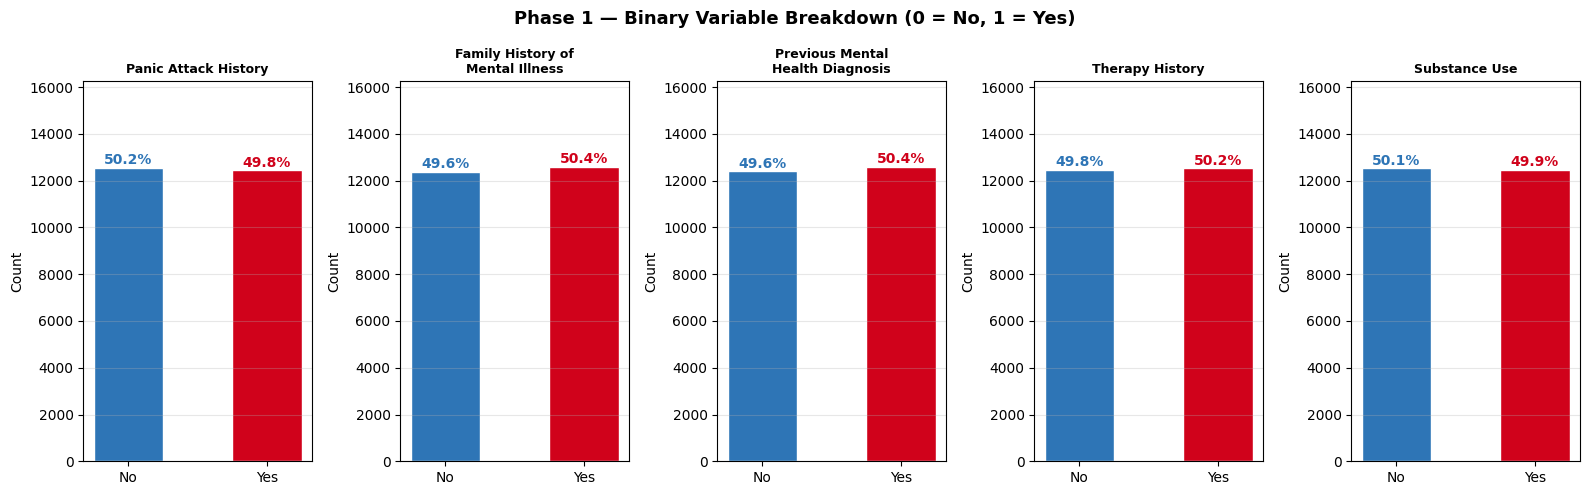

done!


In [2]:
# Phase 1 - Binary Variable Breakdown
# some variables in the dataset are binary - they are either 0 (No) or 1 (Yes)
# i want to check the split between Yes and No for each one
# if one answer makes up 99% of responses the variable won't be useful for analysis
# i'm using bar charts here because there are only two categories per variable
# so a histogram doesn't make sense

import pandas as pd
import matplotlib.pyplot as plt

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# the five binary variables in the dataset
binary_vars = [
    ('panic_attack_history',             'Panic Attack History'),
    ('family_history_mental_illness',    'Family History of\nMental Illness'),
    ('previous_mental_health_diagnosis', 'Previous Mental\nHealth Diagnosis'),
    ('therapy_history',                  'Therapy History'),
    ('substance_use',                    'Substance Use'),
]

# colours for No and Yes bars
colors = ['#2E75B6', '#D0021B']

fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle('Phase 1 — Binary Variable Breakdown (0 = No, 1 = Yes)', fontsize=13, fontweight='bold')

for i, (col, title) in enumerate(binary_vars):

    ax = axes[i]

    # count how many 0s and 1s there are
    counts = df[col].value_counts().sort_index()

    # calculate the percentage for each
    pct_no  = counts[0] / len(df) * 100
    pct_yes = counts[1] / len(df) * 100

    bars = ax.bar(['No', 'Yes'], counts.values,
                  color=colors, edgecolor='white', width=0.5)

    # add the percentage label above each bar
    # i'm using set_ylim first so the labels don't get cut off
    ax.set_ylim(0, len(df) * 0.65)

    ax.text(bars[0].get_x() + bars[0].get_width() / 2,
            bars[0].get_height() + 150,
            f'{pct_no:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#2E75B6')

    ax.text(bars[1].get_x() + bars[1].get_width() / 2,
            bars[1].get_height() + 150,
            f'{pct_yes:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#D0021B')

    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_binary_breakdown.png', dpi=150)
plt.show()

print("done!")

# b) Sanity Checks

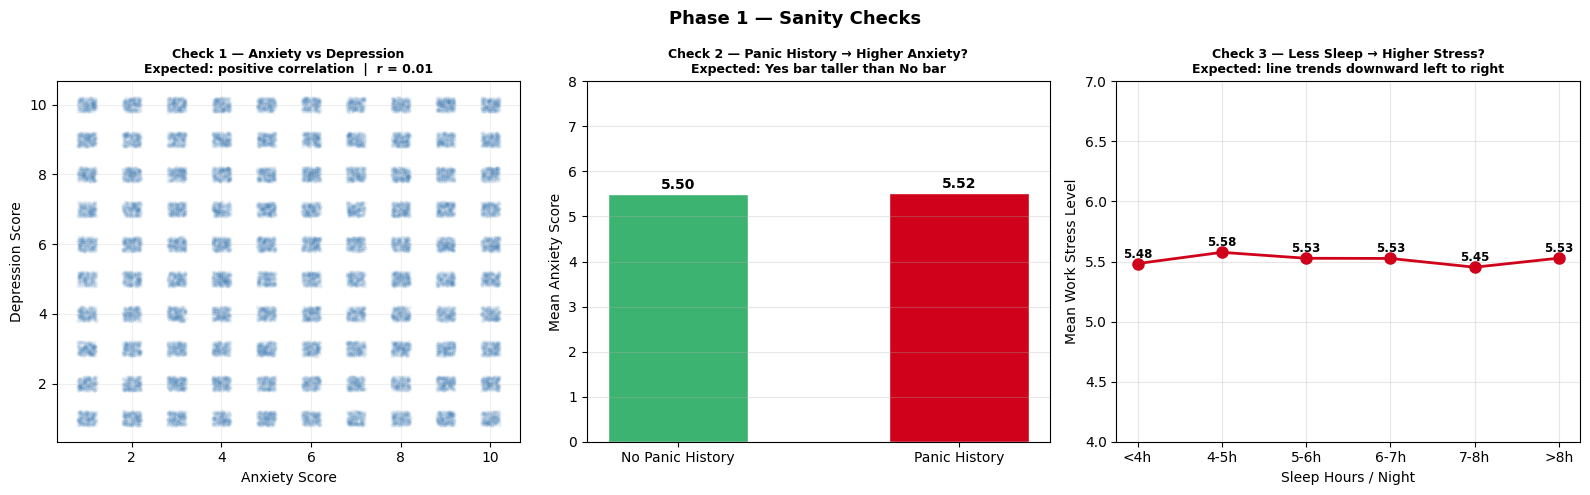

done!


In [5]:
# Phase 1 - Sanity Checks
# before i trust the data for deeper analysis i want to confirm that obvious
# patterns actually exist in the dataset
# my lecturer called these "sanity checks" - basically if these patterns don't show up
# it means something might be wrong with the data
# i picked three checks that seemed obvious to me based on what i already know
# about mental health:
#   1. anxiety and depression scores should be positively correlated
#      - people with high anxiety tend to also have high depression
#   2. people with a panic attack history should have higher anxiety on average
#   3. people who sleep fewer hours should have higher stress levels

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 1 — Sanity Checks', fontsize=13, fontweight='bold')

# -----------------------------------------------------------------------
# sanity check 1 - anxiety vs depression should be positively correlated
# i'm using a scatter plot here so i can see the relationship between the two
# if there's a clear upward trend from left to right the check passes
# -----------------------------------------------------------------------

# adding jitter because both scores are whole numbers so dots stack on top of each other
jitter_x = np.random.uniform(-0.2, 0.2, size=len(df))
jitter_y = np.random.uniform(-0.2, 0.2, size=len(df))

axes[0].scatter(df['anxiety_score'] + jitter_x,
                df['depression_score'] + jitter_y,
                alpha=0.03, color='#2E75B6', s=5)

r = df['anxiety_score'].corr(df['depression_score'])

axes[0].set_title(f'Check 1 — Anxiety vs Depression\nExpected: positive correlation  |  r = {r:.2f}',
                  fontsize=9, fontweight='bold')
axes[0].set_xlabel('Anxiety Score')
axes[0].set_ylabel('Depression Score')
axes[0].grid(alpha=0.2)

# -----------------------------------------------------------------------
# sanity check 2 - panic attack history should mean higher anxiety score
# using a bar chart showing mean anxiety for people with and without panic history
# if the Yes bar is taller than the No bar the check passes
# -----------------------------------------------------------------------

means_anxiety = df.groupby('panic_attack_history')['anxiety_score'].mean()
counts        = df.groupby('panic_attack_history').size()

bars = axes[1].bar(['No Panic History', 'Panic History'],
                   means_anxiety.values,
                   color=['#3CB371', '#D0021B'], edgecolor='white', width=0.5)

# set ylim before adding labels so they don't get clipped
axes[1].set_ylim(0, 8)

for bar, mean in zip(bars, means_anxiety.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{mean:.2f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Check 2 — Panic History → Higher Anxiety?\nExpected: Yes bar taller than No bar',
                  fontsize=9, fontweight='bold')
axes[1].set_ylabel('Mean Anxiety Score')
axes[1].grid(axis='y', alpha=0.3)

# -----------------------------------------------------------------------
# sanity check 3 - less sleep should mean higher stress
# grouping people into sleep bands and plotting mean stress per band
# if the line goes down from left to right the check passes
# -----------------------------------------------------------------------

# bin sleep hours into groups the same way i did in question 2
df['sleep_band'] = pd.cut(df['sleep_hours'],
                          bins=[2, 4, 5, 6, 7, 8, 11],
                          labels=['<4h', '4-5h', '5-6h', '6-7h', '7-8h', '>8h'])

sleep_stress = df.groupby('sleep_band', observed=True)['work_stress_level'].mean()

axes[2].plot(range(len(sleep_stress)), sleep_stress.values,
             'o-', color='#D0021B', linewidth=2, markersize=8)

# add the mean value next to each point
for j, val in enumerate(sleep_stress.values):
    axes[2].text(j, val + 0.05, f'{val:.2f}', ha='center', fontsize=8.5, fontweight='bold')

axes[2].set_xticks(range(len(sleep_stress)))
axes[2].set_xticklabels(sleep_stress.index)
axes[2].set_title('Check 3 — Less Sleep → Higher Stress?\nExpected: line trends downward left to right',
                  fontsize=9, fontweight='bold')
axes[2].set_xlabel('Sleep Hours / Night')
axes[2].set_ylabel('Mean Work Stress Level')
axes[2].set_ylim(4, 7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_sanity_checks.png', dpi=150)
plt.show()

print("done!")

# PHASE 2 :  RESEARCH QUESTION ANALYSIS

# Question 1 : Do Demographics affect mental health risk ?

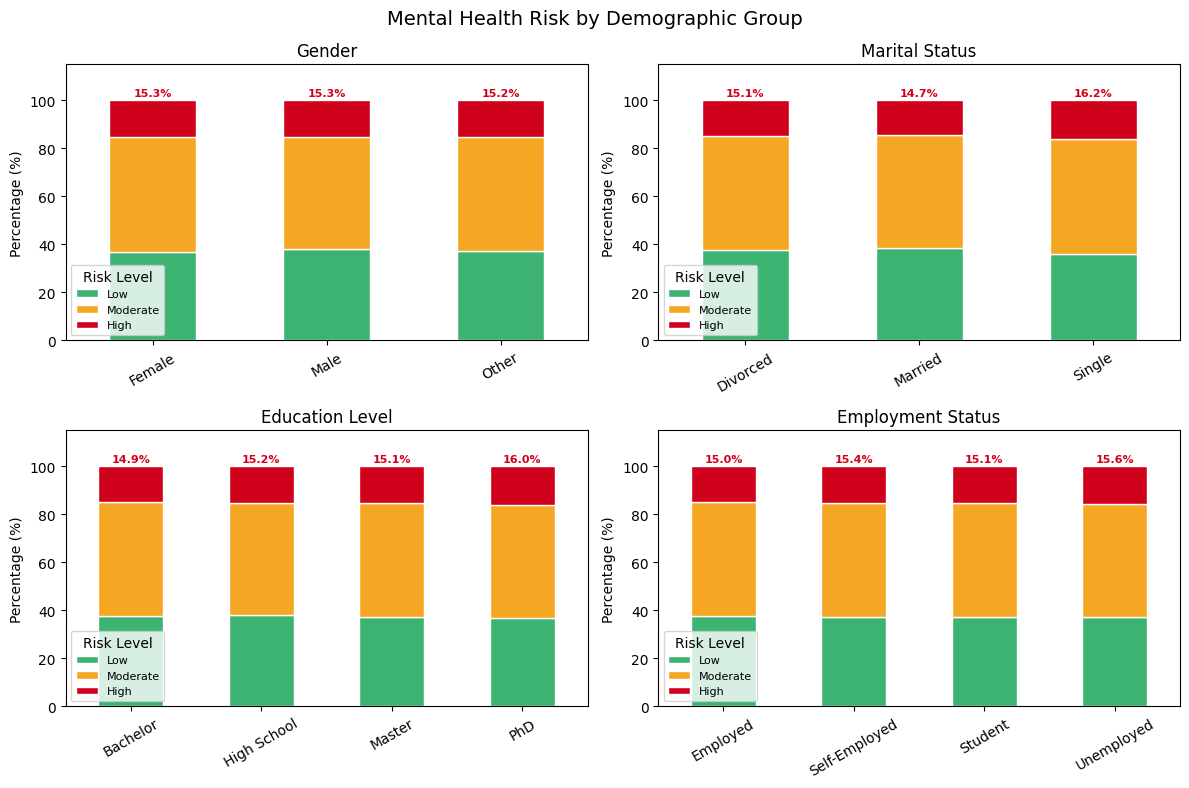

In [9]:
# Question 1 - Do demographics affect mental health risk?
# I want to see how risk levels are spread across different demographic groups
# going to use stacked bar charts for this

import pandas as pd
import matplotlib.pyplot as plt

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# the risk column has numbers 0, 1, 2 so i'm going to rename them
# to make the chart labels easier to read
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

# these are the demographic columns i want to look at
demographic_cols = ['gender', 'marital_status', 'education_level', 'employment_status']

# colours for each risk level - green for low, orange for moderate, red for high
colors = ['#3CB371', '#F5A623', '#D0021B']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Mental Health Risk by Demographic Group', fontsize=14)

# loop through each demographic column and make a stacked bar chart
for i, col in enumerate(demographic_cols):

    ax = axes[i // 2][i % 2]

    # crosstab gives me the count for each combination
    # normalize='index' converts it to percentages within each group
    ct = pd.crosstab(df[col], df['risk_label'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # make sure the columns are in the right order
    ct_pct = ct_pct[['Low', 'Moderate', 'High']]

    ct_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white')

    # set ylim BEFORE adding text labels otherwise matplotlib clips them
    ax.set_ylim(0, 115)

    # add the high risk percentage above each bar
    # i'm looping through each category (each bar) and grabbing the High % value
    for j, category in enumerate(ct_pct.index):
        high_pct = ct_pct.loc[category, 'High']
        ax.text(j, 102, f'{high_pct:.1f}%', ha='center', fontsize=8,
                color='#D0021B', fontweight='bold')

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Risk Level', fontsize=8)

plt.tight_layout()
plt.savefig('q1_demographics.png', dpi=150)
plt.show()

#print("done!")

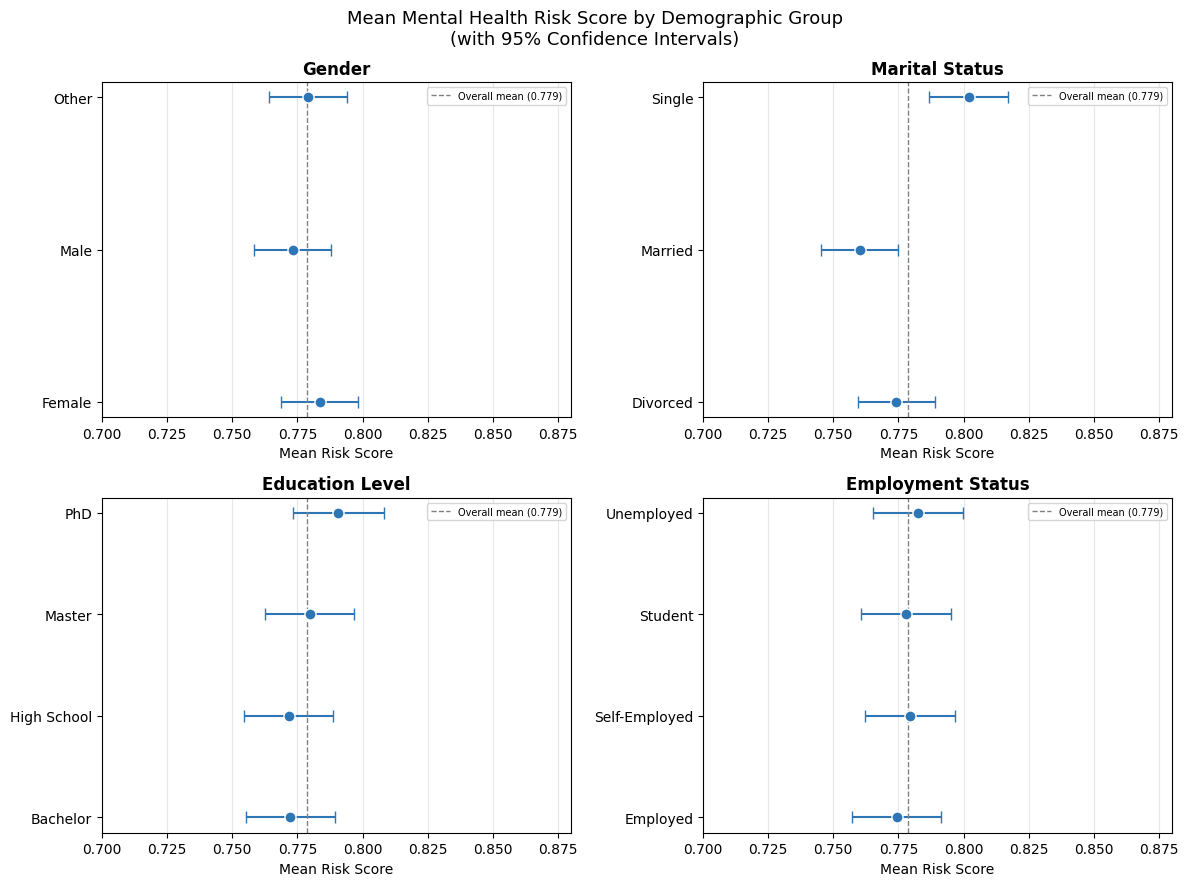

done!


In [3]:
# Question 1 - Refined Visualisation
# the stacked bars were hard to compare across groups because the differences are so small
# so i'm switching to a dot plot that shows the mean risk score for each group
# i'm also adding error bars (95% confidence intervals) to see if the differences are real or just noise

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# these are the groups i want to compare
demographic_cols = ['gender', 'marital_status', 'education_level', 'employment_status']

# calculate the overall mean so i can add a reference line to the chart
overall_mean = df['mental_health_risk'].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Mean Mental Health Risk Score by Demographic Group\n(with 95% Confidence Intervals)', fontsize=13)

for i, col in enumerate(demographic_cols):

    ax = axes[i // 2][i % 2]

    # group by the demographic column and calculate mean + confidence interval
    groups = df.groupby(col)['mental_health_risk']

    means = []
    lower_errors = []
    upper_errors = []
    labels = []

    for name, values in groups:
        mean = values.mean()
        # standard error = std / sqrt(n)
        se = values.std() / np.sqrt(len(values))
        # 95% confidence interval = 1.96 * standard error
        ci = 1.96 * se

        means.append(mean)
        lower_errors.append(ci)
        upper_errors.append(ci)
        labels.append(name)

    # plot the dots with error bars
    y_positions = range(len(labels))
    ax.errorbar(means, y_positions, xerr=[lower_errors, upper_errors],
                fmt='o', color='#2E75B6', markersize=8,
                capsize=4, linewidth=1.5,
                markeredgecolor='white', markeredgewidth=1)

    # add a vertical dashed line for the overall mean so i can see which groups are above/below
    ax.axvline(overall_mean, color='gray', linestyle='--', linewidth=1,
               label=f'Overall mean ({overall_mean:.3f})')

    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Mean Risk Score')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=7)

    # set x axis limits so all charts look the same and are easy to compare
    ax.set_xlim(0.70, 0.88)

    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('q1_refined.png', dpi=150)
plt.show()

print("done!")

# Question 2 :Does Sleep and other lifestyle factors matter to mental health risk

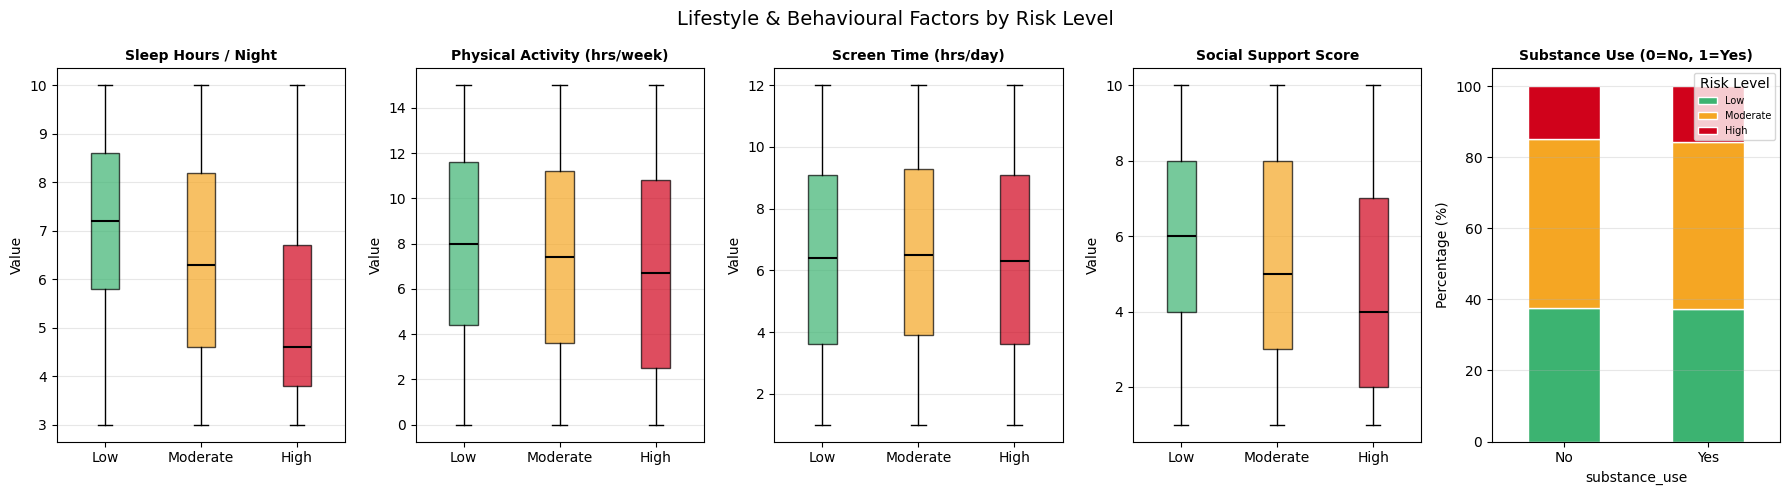

done!


In [5]:
# Question 2 - Does sleep and lifestyle matter?
# i want to look at how lifestyle variables like sleep, physical activity, screen time etc
# differ across the three risk groups
# UPDATE - switched to boxplots for the continuous variables, kept stacked bar for substance use
# since that one is just yes/no it doesn't make sense as a boxplot


import pandas as pd
import matplotlib.pyplot as plt

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

# removed anxiety_score from this list - moved it to question 4
lifestyle_vars = [
    ('sleep_hours',                         'Sleep Hours / Night'),
    ('physical_activity_hours_per_week',    'Physical Activity (hrs/week)'),
    ('screen_time_hours_per_day',           'Screen Time (hrs/day)'),
    ('social_support_score',               'Social Support Score'),
    ('substance_use',                       'Substance Use (0=No, 1=Yes)'),
]

# colours for each risk level
colors      = ['#3CB371', '#F5A623', '#D0021B']
risk_groups = ['Low', 'Moderate', 'High']

# now only 5 variables so i'm using a 1x5 layout instead of 2x3
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Lifestyle & Behavioural Factors by Risk Level', fontsize=14)

for i, (col, title) in enumerate(lifestyle_vars):

    ax = axes[i]

    # substance_use is binary (0 or 1) so a stacked bar makes more sense than a boxplot
    if col == 'substance_use':
        ct     = pd.crosstab(df[col], df['risk_label'])
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        ct_pct = ct_pct[['Low', 'Moderate', 'High']]
        ct_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white')
        ax.set_xticklabels(['No', 'Yes'], rotation=0)
        ax.set_ylabel('Percentage (%)')
        ax.legend(title='Risk Level', fontsize=7)

    # for all the continuous variables use a boxplot
    else:
        low      = df[df['risk_label'] == 'Low'][col].dropna().tolist()
        moderate = df[df['risk_label'] == 'Moderate'][col].dropna().tolist()
        high     = df[df['risk_label'] == 'High'][col].dropna().tolist()

        data = [low, moderate, high]

        # patch_artist=True lets me fill the boxes with colour
        bp = ax.boxplot(data, positions=[0, 1, 2], patch_artist=True,
                        medianprops=dict(color='black', linewidth=1.5))

        # colour each box to match the risk level
        for j, patch in enumerate(bp['boxes']):
            patch.set_facecolor(colors[j])
            patch.set_alpha(0.7)

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(risk_groups)
        ax.set_ylabel('Value')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q2_lifestyle_initial.png', dpi=150)
plt.show()

print("done!")

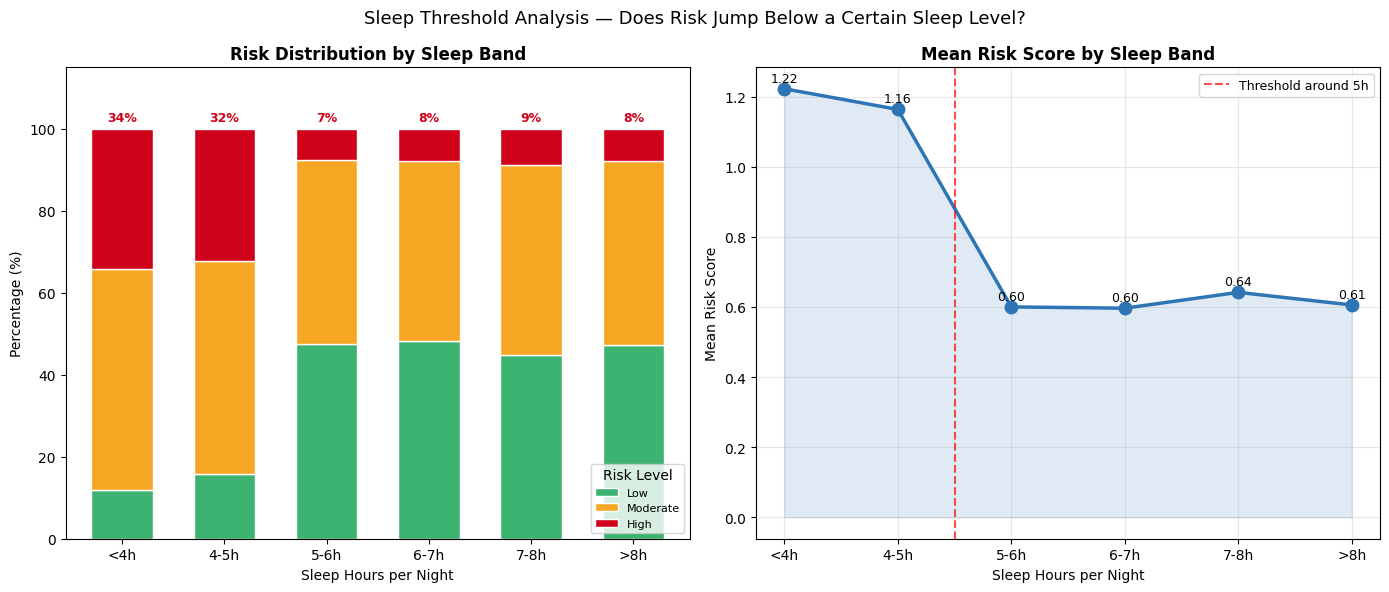

done!


In [5]:
# Question 2 - Refined Visualisation (Sleep Threshold)
# after looking at the violin plots i noticed sleep hours had the biggest difference
# between risk groups so i wanted to dig deeper into this one specifically
# my idea was to group people into sleep bands (like less than 4 hours, 4-5 hours etc)
# and see if there is a specific point where risk suddenly jumps up
# sometimes  relationships aren't always linear - sometimes there's a threshold

import pandas as pd
import matplotlib.pyplot as plt

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

# bin people into sleep categories
# i chose these bands because they felt natural (less than 4, 4-5, 5-6, 6-7, 7-8, more than 8)
df['sleep_category'] = pd.cut(df['sleep_hours'],
                               bins=[2, 4, 5, 6, 7, 8, 11],
                               labels=['<4h', '4-5h', '5-6h', '6-7h', '7-8h', '>8h'])

risk_groups = ['Low', 'Moderate', 'High']
colors = ['#3CB371', '#F5A623', '#D0021B']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sleep Threshold Analysis — Does Risk Jump Below a Certain Sleep Level?', fontsize=13)

# --- chart 1: stacked bar showing risk distribution within each sleep band ---
ct = pd.crosstab(df['sleep_category'], df['risk_label'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct[['Low', 'Moderate', 'High']]

ct_pct.plot(kind='bar', stacked=True, ax=axes[0], color=colors, edgecolor='white', width=0.6)

# set ylim before adding labels so they don't get clipped
axes[0].set_ylim(0, 115)

# add the high risk % above each bar
for j, category in enumerate(ct_pct.index):
    high_pct = ct_pct.loc[category, 'High']
    axes[0].text(j, 102, f'{high_pct:.0f}%', ha='center', fontsize=9,
                 color='#D0021B', fontweight='bold')

axes[0].set_title('Risk Distribution by Sleep Band', fontweight='bold')
axes[0].set_xlabel('Sleep Hours per Night')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Risk Level', fontsize=8)

# --- chart 2: line chart showing mean risk score per sleep band ---
# this makes it easier to see if there's a threshold effect
mean_risk = df.groupby('sleep_category', observed=True)['mental_health_risk'].mean()

axes[1].plot(range(len(mean_risk)), mean_risk.values, 'o-',
             color='#2E75B6', linewidth=2.5, markersize=9)

# shade under the line to make the drop more visible
axes[1].fill_between(range(len(mean_risk)), mean_risk.values, alpha=0.15, color='#2E75B6')

# add a vertical line to mark where i think the threshold is
axes[1].axvline(x=1.5, color='red', linestyle='--', alpha=0.7, label='Threshold around 5h')

# label each point with its mean value
for x, y in enumerate(mean_risk.values):
    axes[1].text(x, y + 0.02, f'{y:.2f}', ha='center', fontsize=9)

axes[1].set_xticks(range(len(mean_risk)))
axes[1].set_xticklabels(mean_risk.index)
axes[1].set_title('Mean Risk Score by Sleep Band', fontweight='bold')
axes[1].set_xlabel('Sleep Hours per Night')
axes[1].set_ylabel('Mean Risk Score')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q2_sleep_threshold.png', dpi=150)
plt.show()

print("done!")

# Question 3 : Does Workload or Stress Cause Higher Risk?

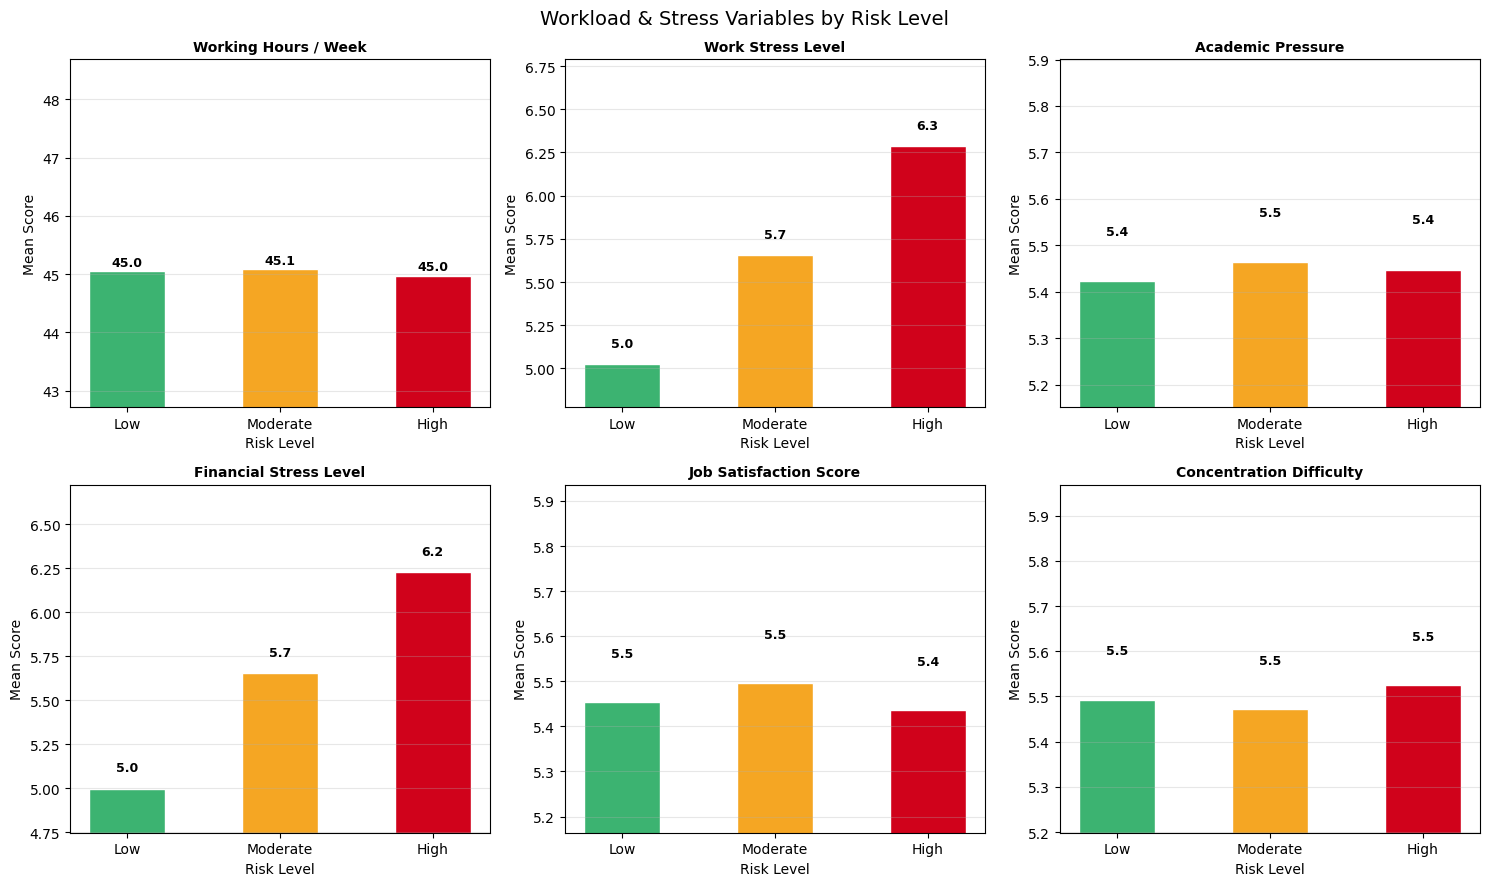

done!


In [8]:
# Question 3 - Initial Visualisation
# i want to see how workload related variables differ across the three risk groups
# i'm using a grouped bar chart so i can compare Low, Moderate and High risk side by side
# for each variable - this makes it easy to spot which variables show the biggest differences

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

# the workload variables i want to look at
workload_vars = [
    ('working_hours_per_week',        'Working Hours / Week'),
    ('work_stress_level',             'Work Stress Level'),
    ('academic_pressure_level',       'Academic Pressure'),
    ('financial_stress_level',        'Financial Stress Level'),
    ('job_satisfaction_score',        'Job Satisfaction Score'),
    ('concentration_difficulty_level','Concentration Difficulty'),
]

# colours for each risk level
colors = ['#3CB371', '#F5A623', '#D0021B']
risk_groups = ['Low', 'Moderate', 'High']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Workload & Stress Variables by Risk Level', fontsize=14)

for i, (col, title) in enumerate(workload_vars):

    ax = axes[i // 3][i % 3]

    # calculate the mean score for each risk group
    means = [df[df['risk_label'] == r][col].mean() for r in risk_groups]

    # set up the bar positions
    # i need to space them out so the bars don't overlap
    x = np.arange(len(risk_groups))
    bars = ax.bar(x, means, color=colors, edgecolor='white', width=0.5)

    # add the mean value on top of each bar so the exact number is visible
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{mean:.1f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(risk_groups)
    ax.set_xlabel('Risk Level')
    ax.set_ylabel('Mean Score')
    ax.grid(axis='y', alpha=0.3)

    # set the y axis to start slightly below the minimum so bars don't look too flat
    min_val = min(means)
    max_val = max(means)
    ax.set_ylim(min_val * 0.95, max_val * 1.08)

plt.tight_layout()
plt.savefig('q3_workload_grouped_bar.png', dpi=150)
plt.show()

print("done!")

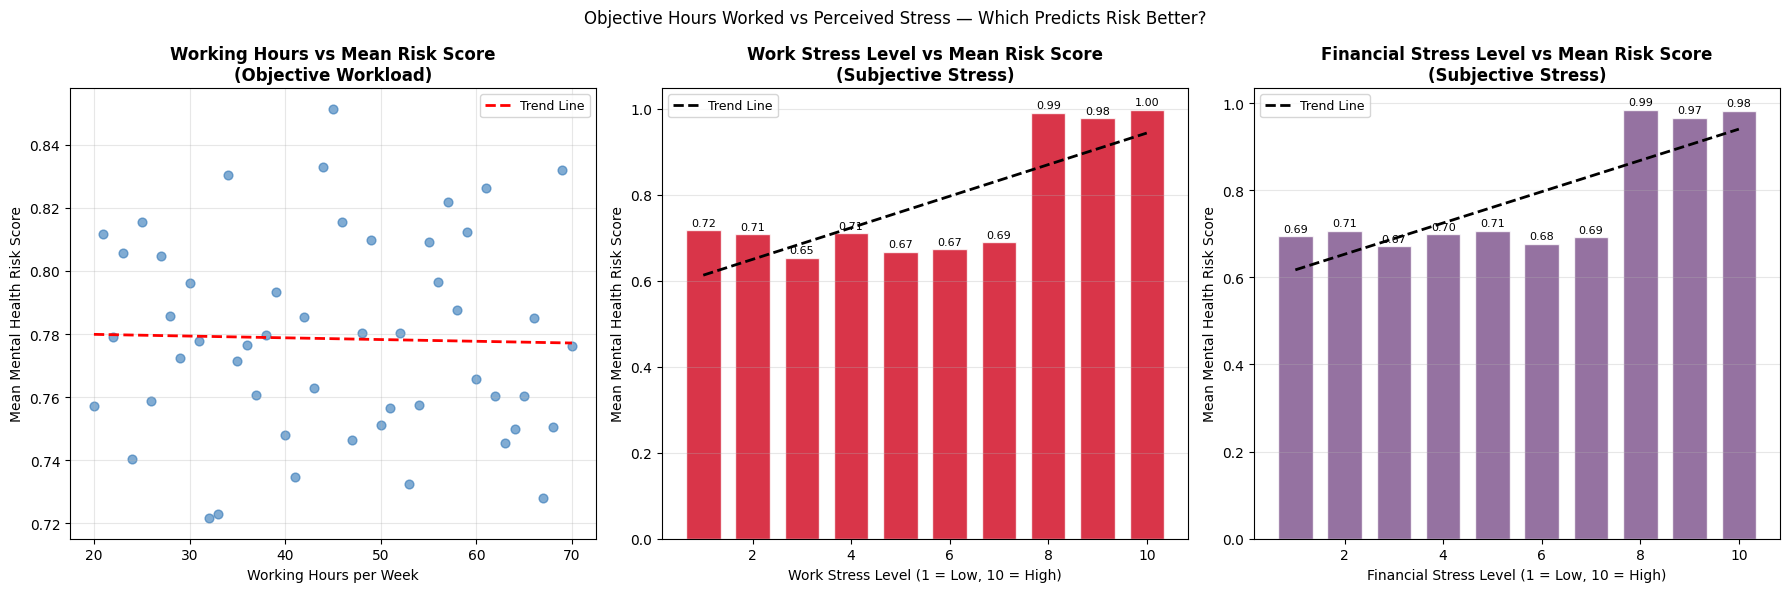

done! - hours worked is basically flat but both stress levels show a clear upward gradient


In [10]:
# Question 3 - Refined Visualisation (Subjective vs Objective)
# after the grouped bar chart i noticed something interesting
# working hours per week looked almost identical across all three risk groups
# but work stress and financial stress showed a clearer difference
# so i wanted to directly compare objective workload (hours worked)
# against subjective stress (how stressed someone feels)
# to see which one actually has a stronger relationship with mental health risk

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Objective Hours Worked vs Perceived Stress — Which Predicts Risk Better?', fontsize=12)

# --- chart 1: working hours vs mean risk (objective) ---
# i'm grouping by working_hours_per_week and calculating the mean risk score for each hour value
# if hours matter the line should go up as hours increase

hours_risk = df.groupby('working_hours_per_week')['mental_health_risk'].mean()

axes[0].scatter(hours_risk.index, hours_risk.values, color='#2E75B6', alpha=0.6, s=40)

# add a regression line to see the overall trend
slope, intercept, r_value, p_value, _ = stats.linregress(
    df['working_hours_per_week'], df['mental_health_risk']
)
x_line = np.linspace(df['working_hours_per_week'].min(), df['working_hours_per_week'].max(), 100)
y_line = slope * x_line + intercept
axes[0].plot(x_line, y_line, color='red', linewidth=2, linestyle='--', label='Trend Line')

axes[0].set_title('Working Hours vs Mean Risk Score\n(Objective Workload)', fontweight='bold')
axes[0].set_xlabel('Working Hours per Week')
axes[0].set_ylabel('Mean Mental Health Risk Score')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# --- chart 2: work stress level vs mean risk (subjective) ---
# now doing the same thing but for work stress level (1-10 scale)
# if stress matters more than hours the line should be steeper here

stress_risk = df.groupby('work_stress_level')['mental_health_risk'].mean()

axes[1].bar(stress_risk.index, stress_risk.values, color='#D0021B',
            edgecolor='white', width=0.7, alpha=0.8)

# add regression line for work stress
slope2, intercept2, r_value2, p_value2, _ = stats.linregress(
    df['work_stress_level'], df['mental_health_risk']
)
x_line2 = np.linspace(df['work_stress_level'].min(), df['work_stress_level'].max(), 100)
y_line2 = slope2 * x_line2 + intercept2
axes[1].plot(x_line2, y_line2, color='black', linewidth=2, linestyle='--', label='Trend Line')

# label each bar with its mean value
for x, y in zip(stress_risk.index, stress_risk.values):
    axes[1].text(x, y + 0.01, f'{y:.2f}', ha='center', fontsize=8)

axes[1].set_title('Work Stress Level vs Mean Risk Score\n(Subjective Stress)', fontweight='bold')
axes[1].set_xlabel('Work Stress Level (1 = Low, 10 = High)')
axes[1].set_ylabel('Mean Mental Health Risk Score')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# --- chart 3: financial stress level vs mean risk (subjective) ---
# adding financial stress as well to see if it shows the same pattern as work stress

fin_risk = df.groupby('financial_stress_level')['mental_health_risk'].mean()

axes[2].bar(fin_risk.index, fin_risk.values, color='#7B4F8A',
            edgecolor='white', width=0.7, alpha=0.8)

# add regression line for financial stress
slope3, intercept3, r_value3, p_value3, _ = stats.linregress(
    df['financial_stress_level'], df['mental_health_risk']
)
x_line3 = np.linspace(df['financial_stress_level'].min(), df['financial_stress_level'].max(), 100)
y_line3 = slope3 * x_line3 + intercept3
axes[2].plot(x_line3, y_line3, color='black', linewidth=2, linestyle='--', label='Trend Line')

# label each bar with its mean value
for x, y in zip(fin_risk.index, fin_risk.values):
    axes[2].text(x, y + 0.01, f'{y:.2f}', ha='center', fontsize=8)

axes[2].set_title('Financial Stress Level vs Mean Risk Score\n(Subjective Stress)', fontweight='bold')
axes[2].set_xlabel('Financial Stress Level (1 = Low, 10 = High)')
axes[2].set_ylabel('Mean Mental Health Risk Score')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q3_subjective_vs_objective.png', dpi=150)
plt.show()

print("done! - hours worked is basically flat but both stress levels show a clear upward gradient")

# QUESTION 4 : Are Clinical History factors the strongest predictors?


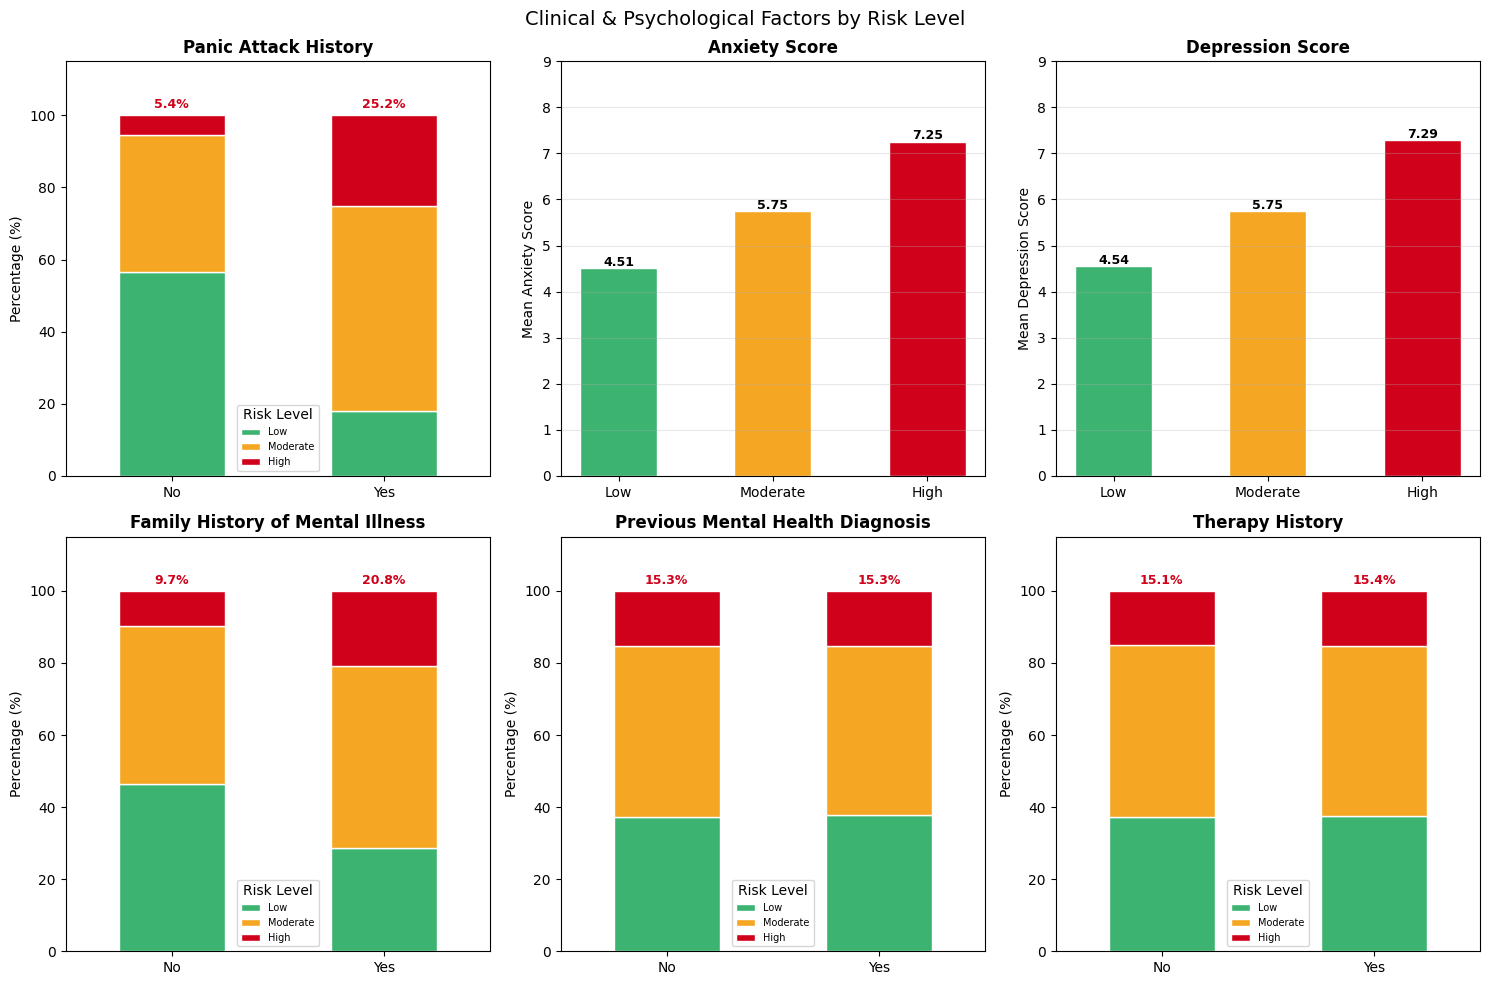

done!


In [11]:
# Question 4 - Are clinical history factors the strongest predictors?
# i want to look at clinical and psychological variables and how they differ across risk groups
# i decided to mix up the chart types this time depending on what made sense for each variable
# binary variables (yes/no) -> stacked bar charts
# score variables (1-10 scale) -> grouped bar charts showing the mean per risk group

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

# colours for each risk level
colors = ['#3CB371', '#F5A623', '#D0021B']
risk_groups = ['Low', 'Moderate', 'High']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Clinical & Psychological Factors by Risk Level', fontsize=14)

# -----------------------------------------------------------------------
# chart 1 - panic attack history (binary -> stacked bar)
# -----------------------------------------------------------------------
ax1 = axes[0][0]

ct = pd.crosstab(df['panic_attack_history'], df['risk_label'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct[['Low', 'Moderate', 'High']]
ct_pct.plot(kind='bar', stacked=True, ax=ax1, color=colors, edgecolor='white', width=0.5)

ax1.set_ylim(0, 115)

# add high risk % above each bar
for j, category in enumerate(ct_pct.index):
    high_pct = ct_pct.loc[category, 'High']
    ax1.text(j, 102, f'{high_pct:.1f}%', ha='center', fontsize=9,
             color='#D0021B', fontweight='bold')

ax1.set_title('Panic Attack History', fontweight='bold')
ax1.set_xticklabels(['No', 'Yes'], rotation=0)
ax1.set_xlabel('')
ax1.set_ylabel('Percentage (%)')
ax1.legend(title='Risk Level', fontsize=7)

# -----------------------------------------------------------------------
# chart 2 - anxiety score (continuous -> grouped bar showing mean per risk group)
# -----------------------------------------------------------------------
ax2 = axes[0][1]

means_anxiety = [df[df['risk_label'] == r]['anxiety_score'].mean() for r in risk_groups]
x = np.arange(len(risk_groups))
bars = ax2.bar(x, means_anxiety, color=colors, edgecolor='white', width=0.5)

# add value labels on top of each bar
for bar, mean in zip(bars, means_anxiety):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{mean:.2f}', ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Anxiety Score', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(risk_groups)
ax2.set_ylabel('Mean Anxiety Score')
ax2.set_ylim(0, 9)
ax2.grid(axis='y', alpha=0.3)

# -----------------------------------------------------------------------
# chart 3 - depression score (continuous -> grouped bar showing mean per risk group)
# -----------------------------------------------------------------------
ax3 = axes[0][2]

means_depression = [df[df['risk_label'] == r]['depression_score'].mean() for r in risk_groups]
bars = ax3.bar(x, means_depression, color=colors, edgecolor='white', width=0.5)

for bar, mean in zip(bars, means_depression):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{mean:.2f}', ha='center', fontsize=9, fontweight='bold')

ax3.set_title('Depression Score', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(risk_groups)
ax3.set_ylabel('Mean Depression Score')
ax3.set_ylim(0, 9)
ax3.grid(axis='y', alpha=0.3)

# -----------------------------------------------------------------------
# chart 4 - family history of mental illness (binary -> stacked bar)
# -----------------------------------------------------------------------
ax4 = axes[1][0]

ct2 = pd.crosstab(df['family_history_mental_illness'], df['risk_label'])
ct_pct2 = ct2.div(ct2.sum(axis=1), axis=0) * 100
ct_pct2 = ct_pct2[['Low', 'Moderate', 'High']]
ct_pct2.plot(kind='bar', stacked=True, ax=ax4, color=colors, edgecolor='white', width=0.5)

ax4.set_ylim(0, 115)

for j, category in enumerate(ct_pct2.index):
    high_pct = ct_pct2.loc[category, 'High']
    ax4.text(j, 102, f'{high_pct:.1f}%', ha='center', fontsize=9,
             color='#D0021B', fontweight='bold')

ax4.set_title('Family History of Mental Illness', fontweight='bold')
ax4.set_xticklabels(['No', 'Yes'], rotation=0)
ax4.set_xlabel('')
ax4.set_ylabel('Percentage (%)')
ax4.legend(title='Risk Level', fontsize=7)

# -----------------------------------------------------------------------
# chart 5 - previous mental health diagnosis (binary -> stacked bar)
# -----------------------------------------------------------------------
ax5 = axes[1][1]

ct3 = pd.crosstab(df['previous_mental_health_diagnosis'], df['risk_label'])
ct_pct3 = ct3.div(ct3.sum(axis=1), axis=0) * 100
ct_pct3 = ct_pct3[['Low', 'Moderate', 'High']]
ct_pct3.plot(kind='bar', stacked=True, ax=ax5, color=colors, edgecolor='white', width=0.5)

ax5.set_ylim(0, 115)

for j, category in enumerate(ct_pct3.index):
    high_pct = ct_pct3.loc[category, 'High']
    ax5.text(j, 102, f'{high_pct:.1f}%', ha='center', fontsize=9,
             color='#D0021B', fontweight='bold')

ax5.set_title('Previous Mental Health Diagnosis', fontweight='bold')
ax5.set_xticklabels(['No', 'Yes'], rotation=0)
ax5.set_xlabel('')
ax5.set_ylabel('Percentage (%)')
ax5.legend(title='Risk Level', fontsize=7)

# -----------------------------------------------------------------------
# chart 6 - therapy history (binary -> stacked bar)
# -----------------------------------------------------------------------
ax6 = axes[1][2]

ct4 = pd.crosstab(df['therapy_history'], df['risk_label'])
ct_pct4 = ct4.div(ct4.sum(axis=1), axis=0) * 100
ct_pct4 = ct_pct4[['Low', 'Moderate', 'High']]
ct_pct4.plot(kind='bar', stacked=True, ax=ax6, color=colors, edgecolor='white', width=0.5)

ax6.set_ylim(0, 115)

for j, category in enumerate(ct_pct4.index):
    high_pct = ct_pct4.loc[category, 'High']
    ax6.text(j, 102, f'{high_pct:.1f}%', ha='center', fontsize=9,
             color='#D0021B', fontweight='bold')

ax6.set_title('Therapy History', fontweight='bold')
ax6.set_xticklabels(['No', 'Yes'], rotation=0)
ax6.set_xlabel('')
ax6.set_ylabel('Percentage (%)')
ax6.legend(title='Risk Level', fontsize=7)

plt.tight_layout()
plt.savefig('q4_clinical_initial.png', dpi=150)
plt.show()

print("done!")

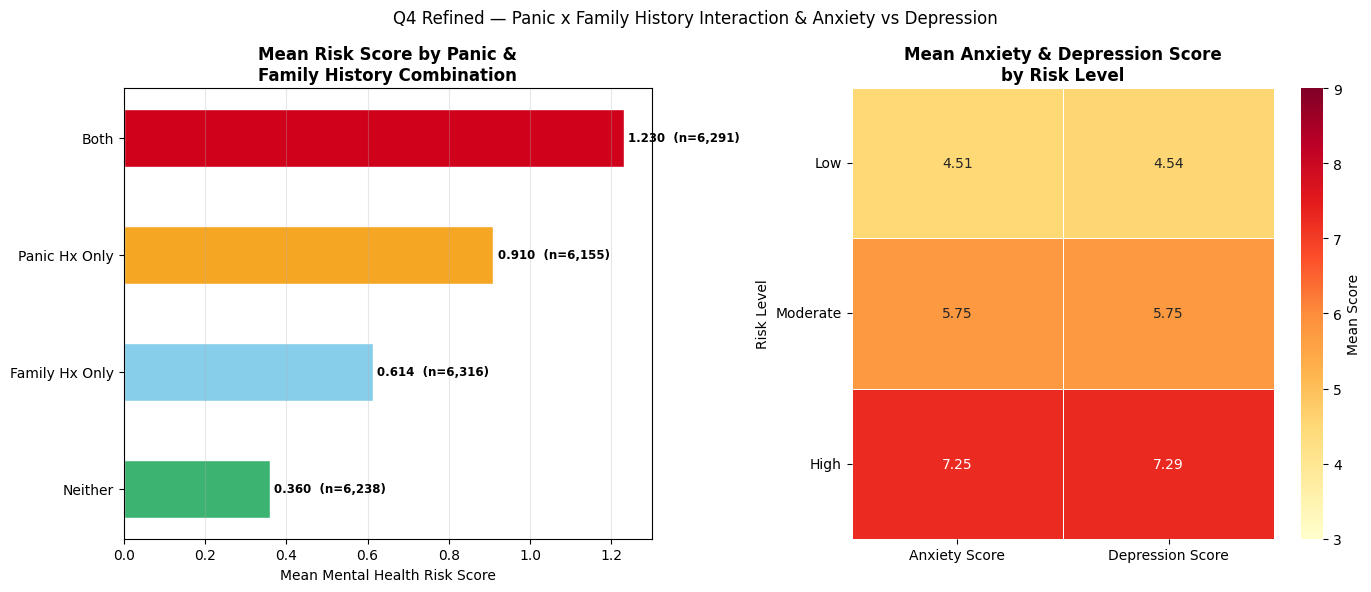

done!


In [14]:
# Question 4 - Refined Visualisation
# after the initial charts i had two follow up questions
# 1. what happens when someone has BOTH a panic attack history AND a family history?
#    does having both make things worse than just having one?
# 2. do anxiety and depression scores move together across the risk groups?
#    switched to a heatmap for this because the scatter plot was too dense to read
# i'm putting both charts side by side so i can discuss them together

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q4 Refined — Panic x Family History Interaction & Anxiety vs Depression', fontsize=12)

# -----------------------------------------------------------------------
# chart 1 - panic attack history x family history interaction
# i'm creating a combined group label so i can compare all 4 combinations
# Panic=0, FamHx=0 -> neither
# Panic=0, FamHx=1 -> family history only
# Panic=1, FamHx=0 -> panic history only
# Panic=1, FamHx=1 -> both
# using horizontal bars so the labels fit without overlapping
# -----------------------------------------------------------------------

df['combo'] = df.apply(lambda row:
    'Neither'          if row['panic_attack_history'] == 0 and row['family_history_mental_illness'] == 0
    else 'Family Hx Only'  if row['panic_attack_history'] == 0 and row['family_history_mental_illness'] == 1
    else 'Panic Hx Only'   if row['panic_attack_history'] == 1 and row['family_history_mental_illness'] == 0
    else 'Both', axis=1
)

# define the order i want the bars to appear in
combo_order = ['Neither', 'Family Hx Only', 'Panic Hx Only', 'Both']
combo_colors = ['#3CB371', '#87CEEB', '#F5A623', '#D0021B']

mean_risk_combo = df.groupby('combo')['mental_health_risk'].mean().reindex(combo_order)
counts = df.groupby('combo').size().reindex(combo_order)

bars = axes[0].barh(combo_order, mean_risk_combo.values,
                    color=combo_colors, edgecolor='white', height=0.5)

# add mean value and sample size at the end of each bar
for bar, mean, n in zip(bars, mean_risk_combo.values, counts.values):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{mean:.3f}  (n={n:,})', va='center', fontsize=8.5, fontweight='bold')

axes[0].set_title('Mean Risk Score by Panic &\nFamily History Combination', fontweight='bold')
axes[0].set_xlabel('Mean Mental Health Risk Score')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.3)
axes[0].grid(axis='x', alpha=0.3)

# -----------------------------------------------------------------------
# chart 2 - heatmap of mean anxiety and depression score per risk level
# this makes it easy to see both scores side by side and whether they rise together
# i'm building a small summary table first then passing it to seaborn heatmap
# -----------------------------------------------------------------------

# calculate the mean anxiety and depression score for each risk group
heatmap_data = df.groupby('risk_label')[['anxiety_score', 'depression_score']].mean()

# reorder rows so it goes Low, Moderate, High
heatmap_data = heatmap_data.reindex(['Low', 'Moderate', 'High'])

# rename columns so the heatmap labels look cleaner
heatmap_data.columns = ['Anxiety Score', 'Depression Score']

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'label': 'Mean Score'}, vmin=3, vmax=9)

axes[1].set_title('Mean Anxiety & Depression Score\nby Risk Level', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Risk Level')
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('q4_clinical_refined.png', dpi=150)
plt.show()

print("done!")

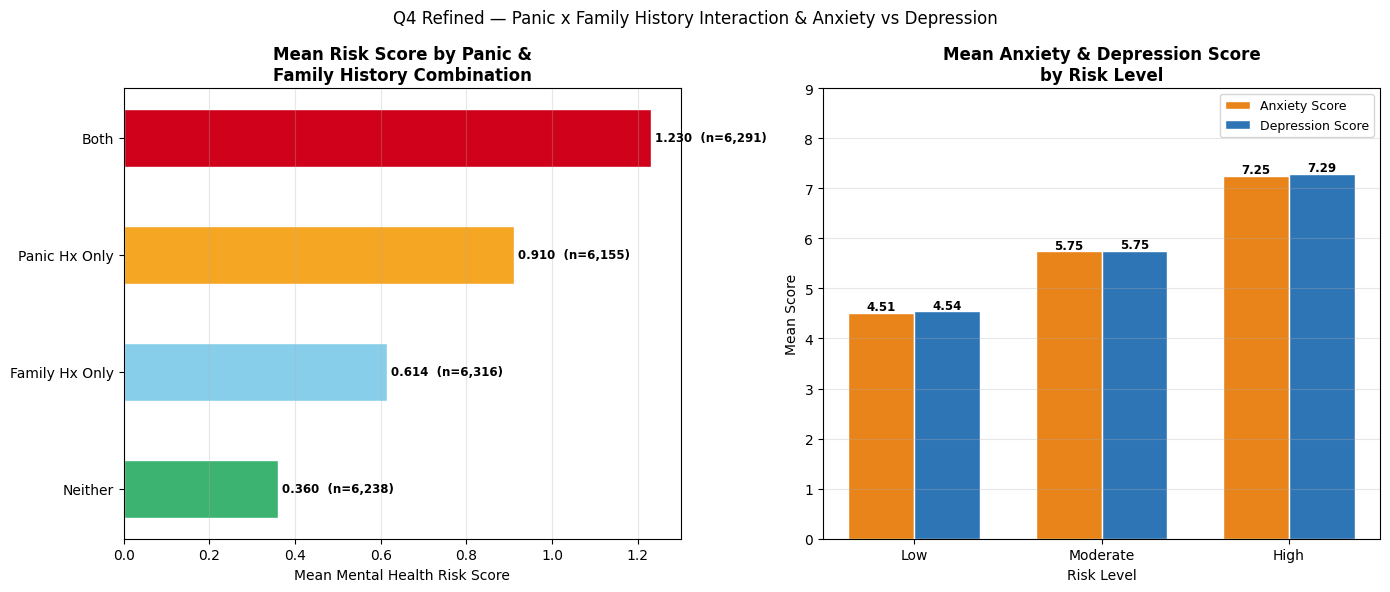

done!


In [15]:
# Question 4 - Refined Visualisation
# after the initial charts i had two follow up questions
# 1. what happens when someone has BOTH a panic attack history AND a family history?
#    does having both make things worse than just having one?
# 2. do anxiety and depression scores move together across the risk groups?
#    using a grouped bar chart so i can see both scores side by side for each risk level
# i'm putting both charts side by side so i can discuss them together

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

risk_groups = ['Low', 'Moderate', 'High']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q4 Refined — Panic x Family History Interaction & Anxiety vs Depression', fontsize=12)

# -----------------------------------------------------------------------
# chart 1 - panic attack history x family history interaction
# i'm creating a combined group label so i can compare all 4 combinations
# Panic=0, FamHx=0 -> neither
# Panic=0, FamHx=1 -> family history only
# Panic=1, FamHx=0 -> panic history only
# Panic=1, FamHx=1 -> both
# using horizontal bars so the labels fit without overlapping
# -----------------------------------------------------------------------

df['combo'] = df.apply(lambda row:
    'Neither'          if row['panic_attack_history'] == 0 and row['family_history_mental_illness'] == 0
    else 'Family Hx Only'  if row['panic_attack_history'] == 0 and row['family_history_mental_illness'] == 1
    else 'Panic Hx Only'   if row['panic_attack_history'] == 1 and row['family_history_mental_illness'] == 0
    else 'Both', axis=1
)

combo_order  = ['Neither', 'Family Hx Only', 'Panic Hx Only', 'Both']
combo_colors = ['#3CB371', '#87CEEB', '#F5A623', '#D0021B']

mean_risk_combo = df.groupby('combo')['mental_health_risk'].mean().reindex(combo_order)
counts          = df.groupby('combo').size().reindex(combo_order)

bars = axes[0].barh(combo_order, mean_risk_combo.values,
                    color=combo_colors, edgecolor='white', height=0.5)

# add mean value and sample size at the end of each bar
for bar, mean, n in zip(bars, mean_risk_combo.values, counts.values):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{mean:.3f}  (n={n:,})', va='center', fontsize=8.5, fontweight='bold')

axes[0].set_title('Mean Risk Score by Panic &\nFamily History Combination', fontweight='bold')
axes[0].set_xlabel('Mean Mental Health Risk Score')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.3)
axes[0].grid(axis='x', alpha=0.3)

# -----------------------------------------------------------------------
# chart 2 - grouped bar chart of mean anxiety and depression per risk group
# two bars per risk group - one for anxiety, one for depression
# this makes it easy to see if they rise together as risk increases
# -----------------------------------------------------------------------

mean_anxiety    = [df[df['risk_label'] == r]['anxiety_score'].mean()    for r in risk_groups]
mean_depression = [df[df['risk_label'] == r]['depression_score'].mean() for r in risk_groups]

# i need to offset the bars so they sit next to each other not on top
x       = np.arange(len(risk_groups))
width   = 0.35

bars1 = axes[1].bar(x - width / 2, mean_anxiety,    width, label='Anxiety Score',
                    color='#E8841A', edgecolor='white')
bars2 = axes[1].bar(x + width / 2, mean_depression, width, label='Depression Score',
                    color='#2E75B6', edgecolor='white')

# add value labels on top of each bar
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8.5, fontweight='bold')

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8.5, fontweight='bold')

axes[1].set_title('Mean Anxiety & Depression Score\nby Risk Level', fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Mean Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(risk_groups)
axes[1].set_ylim(0, 9)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q4_clinical_refined.png', dpi=150)
plt.show()

print("done!")

# Question 5 :Overall, What Matters Most?

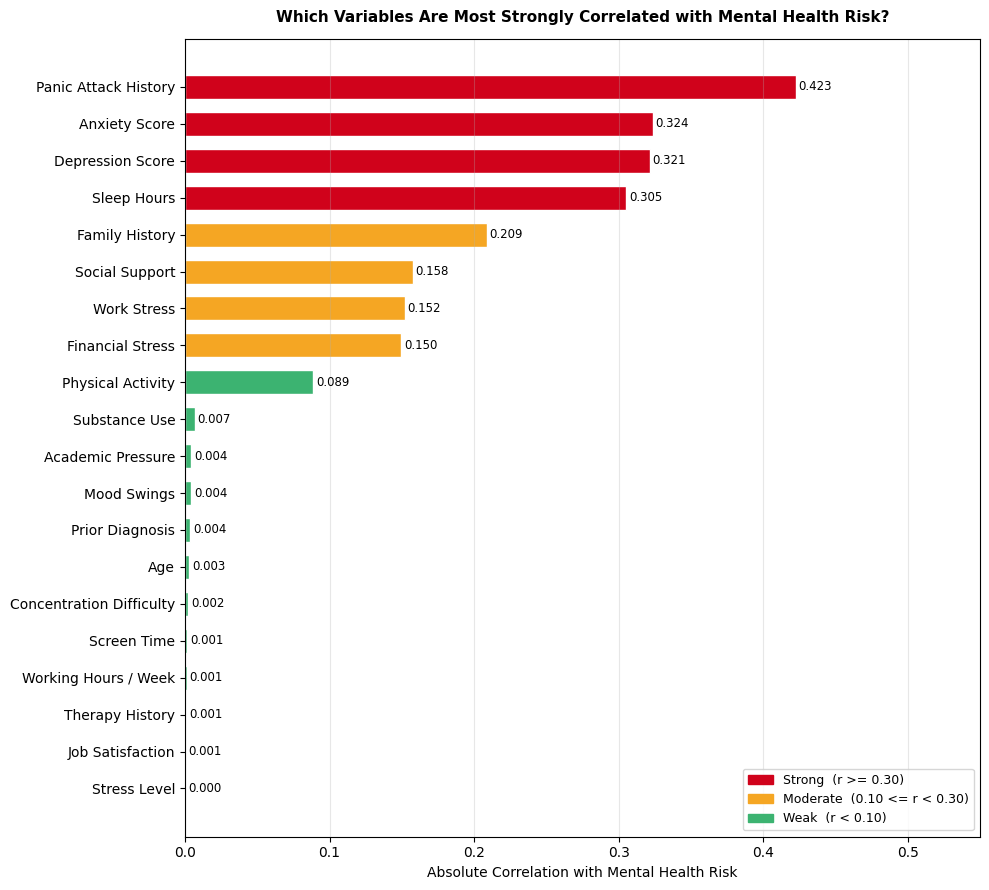

done!


In [16]:
# Question 5 - Overall what matters most?
# i want to rank all the variables in the dataset by how strongly they are related
# to mental health risk
# i haven't learned about ANOVA yet so i'm using Pearson correlation instead
# correlation tells you how strongly two variables move together
# a value close to 1 or -1 means strong relationship, close to 0 means weak
# i'm using the absolute value so that negative correlations (like sleep) still rank high

import pandas as pd
import matplotlib.pyplot as plt

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# these are all the numeric variables i want to check
# i'm leaving out the categorical ones like gender and marital status
# because correlation doesn't work well with text categories
numeric_vars = [
    'age',
    'sleep_hours',
    'physical_activity_hours_per_week',
    'screen_time_hours_per_day',
    'social_support_score',
    'work_stress_level',
    'academic_pressure_level',
    'job_satisfaction_score',
    'financial_stress_level',
    'working_hours_per_week',
    'anxiety_score',
    'depression_score',
    'stress_level',
    'mood_swings_frequency',
    'concentration_difficulty_level',
    'panic_attack_history',
    'family_history_mental_illness',
    'previous_mental_health_diagnosis',
    'therapy_history',
    'substance_use',
]

# nicer labels for the chart
var_labels = {
    'age':                              'Age',
    'sleep_hours':                      'Sleep Hours',
    'physical_activity_hours_per_week': 'Physical Activity',
    'screen_time_hours_per_day':        'Screen Time',
    'social_support_score':             'Social Support',
    'work_stress_level':                'Work Stress',
    'academic_pressure_level':          'Academic Pressure',
    'job_satisfaction_score':           'Job Satisfaction',
    'financial_stress_level':           'Financial Stress',
    'working_hours_per_week':           'Working Hours / Week',
    'anxiety_score':                    'Anxiety Score',
    'depression_score':                 'Depression Score',
    'stress_level':                     'Stress Level',
    'mood_swings_frequency':            'Mood Swings',
    'concentration_difficulty_level':   'Concentration Difficulty',
    'panic_attack_history':             'Panic Attack History',
    'family_history_mental_illness':    'Family History',
    'previous_mental_health_diagnosis': 'Prior Diagnosis',
    'therapy_history':                  'Therapy History',
    'substance_use':                    'Substance Use',
}

# calculate the correlation of each variable with mental_health_risk
# i'm using absolute value because i want to rank by strength not direction
correlations = []

for var in numeric_vars:
    corr = df[var].corr(df['mental_health_risk'])
    correlations.append({'variable': var_labels[var], 'correlation': abs(corr)})

# put it in a dataframe and sort from highest to lowest
corr_df = pd.DataFrame(correlations)
corr_df = corr_df.sort_values('correlation', ascending=True)

# colour code the bars by how strong the correlation is
# i'm doing this manually so the chart is easier to read
def get_color(val):
    if val >= 0.3:
        return '#D0021B'    # strong - red
    elif val >= 0.1:
        return '#F5A623'    # moderate - orange
    else:
        return '#3CB371'    # weak - green

bar_colors = [get_color(v) for v in corr_df['correlation']]

fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(corr_df['variable'], corr_df['correlation'],
               color=bar_colors, edgecolor='white', height=0.65)

# add the correlation value at the end of each bar
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}', va='center', fontsize=8.5)

# add a legend manually to explain the colours
from matplotlib.patches import Patch
legend_items = [
    Patch(color='#D0021B', label='Strong  (r >= 0.30)'),
    Patch(color='#F5A623', label='Moderate  (0.10 <= r < 0.30)'),
    Patch(color='#3CB371', label='Weak  (r < 0.10)'),
]
ax.legend(handles=legend_items, fontsize=9, loc='lower right')

ax.set_xlabel('Absolute Correlation with Mental Health Risk', fontsize=10)
ax.set_title('Which Variables Are Most Strongly Correlated with Mental Health Risk?',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlim(0, 0.55)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('q5_feature_importance.png', dpi=150)
plt.show()

print("done!")

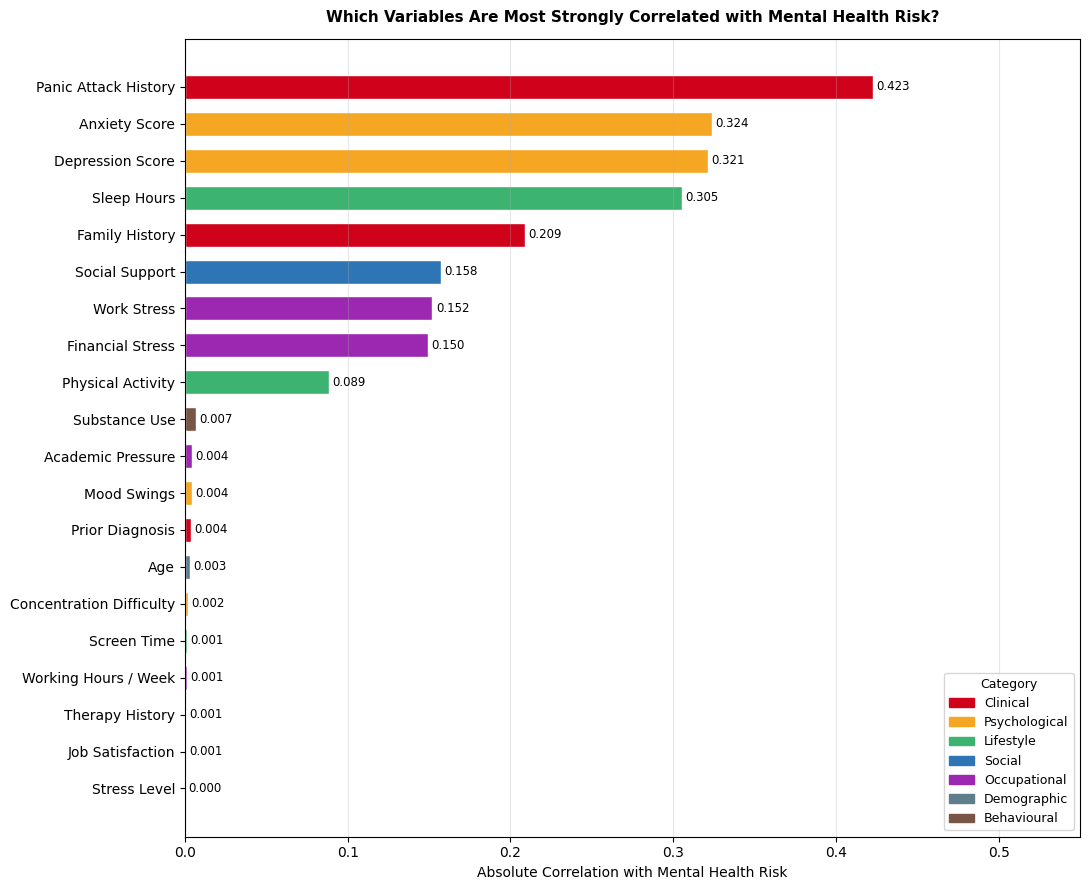

done!


In [17]:
# Question 5 - Overall what matters most?
# i want to rank all the variables in the dataset by how strongly they are related
# to mental health risk
# i haven't learned about ANOVA yet so i'm using Pearson correlation instead
# correlation tells you how strongly two variables move together
# a value close to 1 or -1 means strong relationship, close to 0 means weak
# i'm using the absolute value so that negative correlations (like sleep) still rank high
# i also want to colour code the bars by category so i can see which TYPE of variable
# matters most - clinical, psychological, lifestyle etc

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# these are all the numeric variables i want to check
# i'm leaving out the categorical ones like gender and marital status
# because correlation doesn't work well with text categories
numeric_vars = [
    'age',
    'sleep_hours',
    'physical_activity_hours_per_week',
    'screen_time_hours_per_day',
    'social_support_score',
    'work_stress_level',
    'academic_pressure_level',
    'job_satisfaction_score',
    'financial_stress_level',
    'working_hours_per_week',
    'anxiety_score',
    'depression_score',
    'stress_level',
    'mood_swings_frequency',
    'concentration_difficulty_level',
    'panic_attack_history',
    'family_history_mental_illness',
    'previous_mental_health_diagnosis',
    'therapy_history',
    'substance_use',
]

# nicer labels for the chart
var_labels = {
    'age':                              'Age',
    'sleep_hours':                      'Sleep Hours',
    'physical_activity_hours_per_week': 'Physical Activity',
    'screen_time_hours_per_day':        'Screen Time',
    'social_support_score':             'Social Support',
    'work_stress_level':                'Work Stress',
    'academic_pressure_level':          'Academic Pressure',
    'job_satisfaction_score':           'Job Satisfaction',
    'financial_stress_level':           'Financial Stress',
    'working_hours_per_week':           'Working Hours / Week',
    'anxiety_score':                    'Anxiety Score',
    'depression_score':                 'Depression Score',
    'stress_level':                     'Stress Level',
    'mood_swings_frequency':            'Mood Swings',
    'concentration_difficulty_level':   'Concentration Difficulty',
    'panic_attack_history':             'Panic Attack History',
    'family_history_mental_illness':    'Family History',
    'previous_mental_health_diagnosis': 'Prior Diagnosis',
    'therapy_history':                  'Therapy History',
    'substance_use':                    'Substance Use',
}

# assign each variable to a category
# i decided on these groupings based on what the variable is measuring
var_categories = {
    'Age':                    'Demographic',
    'Sleep Hours':            'Lifestyle',
    'Physical Activity':      'Lifestyle',
    'Screen Time':            'Lifestyle',
    'Social Support':         'Social',
    'Work Stress':            'Occupational',
    'Academic Pressure':      'Occupational',
    'Job Satisfaction':       'Occupational',
    'Financial Stress':       'Occupational',
    'Working Hours / Week':   'Occupational',
    'Anxiety Score':          'Psychological',
    'Depression Score':       'Psychological',
    'Stress Level':           'Psychological',
    'Mood Swings':            'Psychological',
    'Concentration Difficulty':'Psychological',
    'Panic Attack History':   'Clinical',
    'Family History':         'Clinical',
    'Prior Diagnosis':        'Clinical',
    'Therapy History':        'Clinical',
    'Substance Use':          'Behavioural',
}

# one colour per category
category_colors = {
    'Clinical':       '#D0021B',
    'Psychological':  '#F5A623',
    'Lifestyle':      '#3CB371',
    'Social':         '#2E75B6',
    'Occupational':   '#9C27B0',
    'Demographic':    '#607D8B',
    'Behavioural':    '#795548',
}

# calculate the correlation of each variable with mental_health_risk
# using absolute value to rank by strength regardless of direction
correlations = []

for var in numeric_vars:
    label    = var_labels[var]
    corr     = df[var].corr(df['mental_health_risk'])
    category = var_categories[label]
    correlations.append({
        'variable': label,
        'correlation': abs(corr),
        'category': category,
    })

# put it in a dataframe and sort from lowest to highest
# (lowest at top so the strongest bar ends up at the bottom where your eye goes first)
corr_df = pd.DataFrame(correlations)
corr_df  = corr_df.sort_values('correlation', ascending=True)

# get the bar colour based on category
bar_colors = [category_colors[cat] for cat in corr_df['category']]

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(corr_df['variable'], corr_df['correlation'],
               color=bar_colors, edgecolor='white', height=0.65)

# add the correlation value at the end of each bar
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}', va='center', fontsize=8.5)

# category legend
category_legend = [Patch(color=color, label=cat)
                   for cat, color in category_colors.items()]
ax.legend(handles=category_legend, title='Category', fontsize=9,
          title_fontsize=9, loc='lower right')

ax.set_xlabel('Absolute Correlation with Mental Health Risk', fontsize=10)
ax.set_title('Which Variables Are Most Strongly Correlated with Mental Health Risk?',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlim(0, 0.55)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('q5_feature_importance.png', dpi=150)
plt.show()

print("done!")

# QUESTION 6

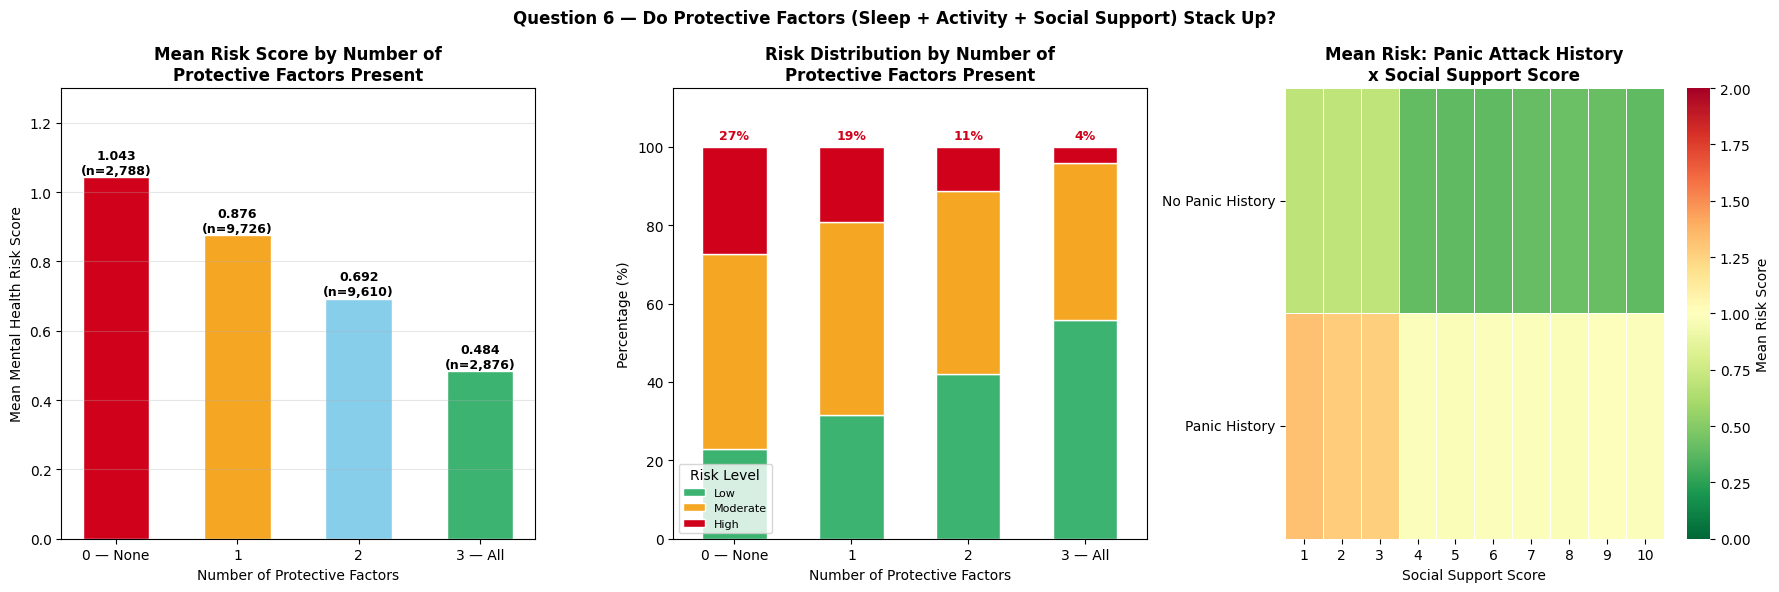

done! - having all 3 protective factors nearly halves the mean risk score compared to having none
the heatmap also shows that high social support reduces risk even for people with panic history


In [3]:
# Question 6 (New) - Do protective factors stack up?
# this question came up while i was doing the earlier analysis
# i noticed that sleep, social support and physical activity all individually
# seemed to reduce risk so i wanted to test if having all three together
# made things even better
# i defined a protective factor as:
#   - sleeping 7 or more hours
#   - doing 5 or more hours of physical activity per week
#   - having a social support score of 7 or above
# each person gets a score from 0 to 3 depending on how many they have
# i also added a third chart looking at whether social support buffers the risk
# for people with a panic attack history - interaction effect

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# load the dataset
df = pd.read_csv('mental_health_risk_dataset.csv')

# map the risk numbers to labels
df['risk_label'] = df['mental_health_risk'].map({0: 'Low', 1: 'Moderate', 2: 'High'})

# create the three protective factor columns
# each one is 1 if the person meets the threshold, 0 if not
df['good_sleep']   = (df['sleep_hours'] >= 7).astype(int)
df['active']       = (df['physical_activity_hours_per_week'] >= 5).astype(int)
df['good_support'] = (df['social_support_score'] >= 7).astype(int)

# add them up to get the total protective factor count (0, 1, 2 or 3)
df['protective_count'] = df['good_sleep'] + df['active'] + df['good_support']

# colours going from red (no factors) to green (all factors)
colors       = ['#D0021B', '#F5A623', '#87CEEB', '#3CB371']
risk_colors  = ['#3CB371', '#F5A623', '#D0021B']
count_labels = ['0 — None', '1', '2', '3 — All']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Question 6 — Do Protective Factors (Sleep + Activity + Social Support) Stack Up?',
             fontsize=12, fontweight='bold')

# -----------------------------------------------------------------------
# chart 1 - mean risk score by protective factor count
# this shows whether having more protective factors lowers risk
# -----------------------------------------------------------------------

mean_risk = df.groupby('protective_count')['mental_health_risk'].mean()
counts    = df.groupby('protective_count').size()

bars = axes[0].bar(count_labels, mean_risk.values,
                   color=colors, edgecolor='white', width=0.55)

# add the mean value and sample size above each bar
for bar, mean, n in zip(bars, mean_risk.values, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{mean:.3f}\n(n={n:,})', ha='center', fontsize=9, fontweight='bold')

axes[0].set_title('Mean Risk Score by Number of\nProtective Factors Present', fontweight='bold')
axes[0].set_xlabel('Number of Protective Factors')
axes[0].set_ylabel('Mean Mental Health Risk Score')
axes[0].set_ylim(0, 1.3)
axes[0].grid(axis='y', alpha=0.3)

# -----------------------------------------------------------------------
# chart 2 - stacked bar showing risk distribution at each protective factor level
# this shows the full breakdown of Low / Moderate / High within each group
# -----------------------------------------------------------------------

ct     = pd.crosstab(df['protective_count'], df['risk_label'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct[['Low', 'Moderate', 'High']]
ct_pct.index = count_labels

ct_pct.plot(kind='bar', stacked=True, ax=axes[1],
            color=risk_colors, edgecolor='white', width=0.55)

# set ylim before labels so they don't get clipped
axes[1].set_ylim(0, 115)

# add high risk % above each bar
for j, label in enumerate(count_labels):
    high_pct = ct_pct.loc[label, 'High']
    axes[1].text(j, 102, f'{high_pct:.0f}%', ha='center', fontsize=9,
                 color='#D0021B', fontweight='bold')

axes[1].set_title('Risk Distribution by Number of\nProtective Factors Present', fontweight='bold')
axes[1].set_xlabel('Number of Protective Factors')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Risk Level', fontsize=8)

# -----------------------------------------------------------------------
# chart 3 - mean risk: panic attack history x social support interaction
# i want to see if high social support reduces risk even for people
# who already have a panic attack history
# i'm using a heatmap - rows = panic history (yes/no), columns = social support score
# -----------------------------------------------------------------------

# pivot table: for each combination of panic_attack_history and social_support_score
# calculate the mean mental_health_risk
pivot = df.pivot_table(
    index='panic_attack_history',
    columns='social_support_score',
    values='mental_health_risk',
    aggfunc='mean'
)

# rename the row index so the heatmap labels are clearer
pivot.index = ['No Panic History', 'Panic History']

sns.heatmap(pivot, ax=axes[2], cmap='RdYlGn_r',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Mean Risk Score'},
            vmin=0, vmax=2)

axes[2].set_title('Mean Risk: Panic Attack History\nx Social Support Score', fontweight='bold')
axes[2].set_xlabel('Social Support Score')
axes[2].set_ylabel('')
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('q6_protective_factors.png', dpi=150)
plt.show()

print("done! - having all 3 protective factors nearly halves the mean risk score compared to having none")
print("the heatmap also shows that high social support reduces risk even for people with panic history")